<a href="https://colab.research.google.com/github/DajahV/Multiple_Linear_Regression/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perform Multiple Linear Regression

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
filepath = '/content/drive/MyDrive/DHF 3mtt Projects/Marketing Sales Data/marketing_sales_data.csv'

## Step 1 - Importing modules and packages

In [7]:
# Import libraries and modules.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [5]:
df = pd.read_csv(filepath)

In [6]:
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [8]:
df.tail()

,TV,Radio,Social Media,Influencer,Sales
567,Medium,14.656633,3.817980,Micro,191.521266
568,High,28.110171,7.358169,Mega,297.626731
569,Medium,11.401084,5.818697,Nano,145.416851
570,Medium,21.119991,5.703028,Macro,209.326830
571,Low,13.221237,3.660566,Micro,135.773151


In [10]:
df.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


In [12]:
# Display number of rows, number of columns.
df.shape

(572, 5)

In [13]:
# Which columns contain null values and how many

df.isna().sum()

,0
TV,0
Radio,0
Social Media,0
Influencer,0
Sales,0


#### Based on the validation check performed, the dataset does not contain any missing values or empty rows. This indicates that all records are complete, with no null entries or blank observations across the data structure.

## Step 2 - Exploratory Data Analysis

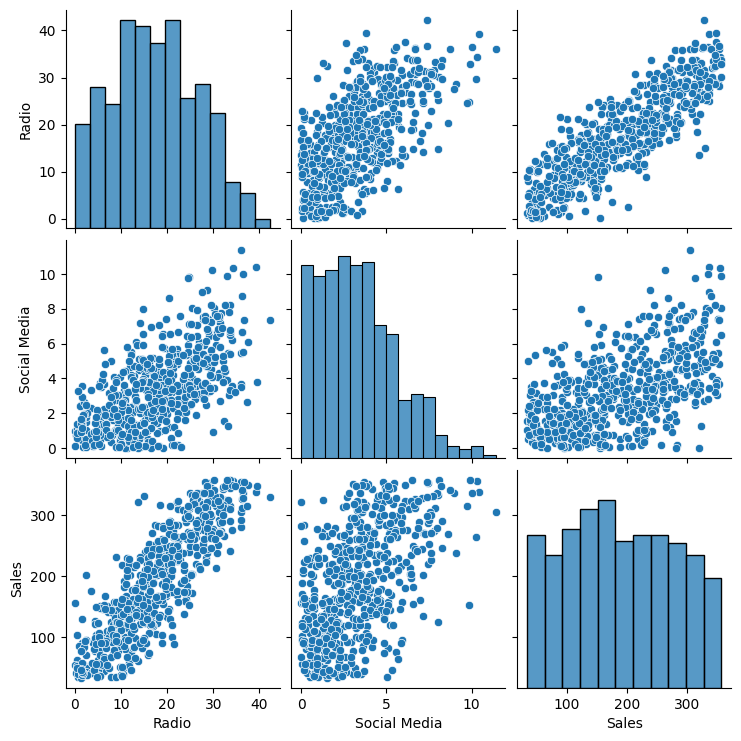

In [14]:
sns.pairplot(df);

Key insights:

Radio and Social Media both appear to have linear relationships with Sales. Given this, Radio and Social Media may be useful as independent variables in a multiple linear regression model estimating Sales.

TV and Influencer are excluded from the pairplot because they are not numeric.

Calculate the mean sales for each categorical variable

In [15]:
# Calculate the mean sales for each TV category.
print(df.groupby('TV')['Sales'].mean())

print('')

# Calculate the mean sales for each Influencer category .

print(df.groupby('Influencer')['Sales'].mean())

TV
High      300.853195
Low        90.984101
Medium    195.358032
Name: Sales, dtype: float64

Influencer
Macro    181.670070
Mega     194.487941
Micro    188.321846
Nano     191.874432
Name: Sales, dtype: float64


Key insights:

The average Sales for High TV promotions is considerably higher than for Medium and Low TV promotions. TV may be a strong predictor of Sales.
The categories for Influencer have different average Sales, but the variation is not substantial. Influencer may be a weak predictor of Sales.

In [16]:
# Rename all columns in data that contain a space.

data = df.rename(columns={'Social Media': 'Social_Media'})

## Step 3 - Model Building

Fit a multiple linear regression model that predicts sales

In [17]:
# Define the OLS formula.

ols_formula = 'Sales ~ C(TV) + Radio'

# Create an OLS model.

OLS = ols(formula = ols_formula, data = data)

# Fit the model.

model = OLS.fit()

# Save the results summary.

model_results = model.summary()

# Display the model results.

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          1.63e-288
Time:                        12:41:17   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.5261      6.261     34.902      0.000     206.228     230.824
C(TV)[T.Low]     -154.2971      4.929    -31.303      0.000    -163.979    -144.616
C(TV)[T.Medium]   -75.3120      3.624    -20.780      0.000     -82.431     -68.193
Radio               2.9669      0.212     14.015      0.000       2.551       3.383
==============================================================================
Omnibus:                       61.244   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.077
Skew:                           0.046   Prob(JB):                     0.000119
Kurtosis:                       2.134   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Key insights:

* TV was selected, as the preceding analysis showed a strong relationship between the TV promotional budget and the average Sales.
* Radio was selected because the pairplot showed a strong linear relationship between Radio and Sales.
Social Media was not selected because it did not increase model performance and it was later determined to be correlated with another independent variable: Radio.
* Influencer was not selected because it did not show a strong relationship to Sales in the preceding analysis.

Check model assumptions

Model assumption: Linearity

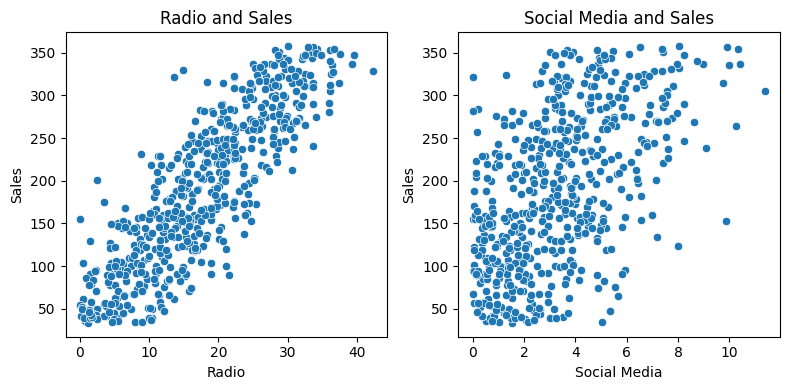

In [18]:
# Create a scatterplot for each independent variable and the dependent variable.

# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a scatterplot between Radio and Sales.
sns.scatterplot(x = data['Radio'], y = data['Sales'],ax=axes[0])

# Set the title of the first plot.
axes[0].set_title("Radio and Sales")

# Create a scatterplot between Social Media and Sales.
sns.scatterplot(x = data['Social_Media'], y = data['Sales'],ax=axes[1])

# Set the title of the second plot.
axes[1].set_title("Social Media and Sales")

# Set the xlabel of the second plot.
axes[1].set_xlabel("Social Media")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()

Key insight:

The linearity assumption holds for Radio, as there is a clear linear relationship in the scatterplot between Radio and Sales. Social Media was not included in the preceding multiple linear regression model, but it does appear to have a linear relationship with Sales.

Model assumption: Independence

The independent observation assumption states that each observation in the dataset is independent. As each marketing promotion (i.e., row) is independent from one another, the independence assumption is not violated.

Model assumption: Normality

I create the following plots to check the normality assumption:

* Plot 1: Histogram of the residuals
* Plot 2: Q-Q plot of the residuals

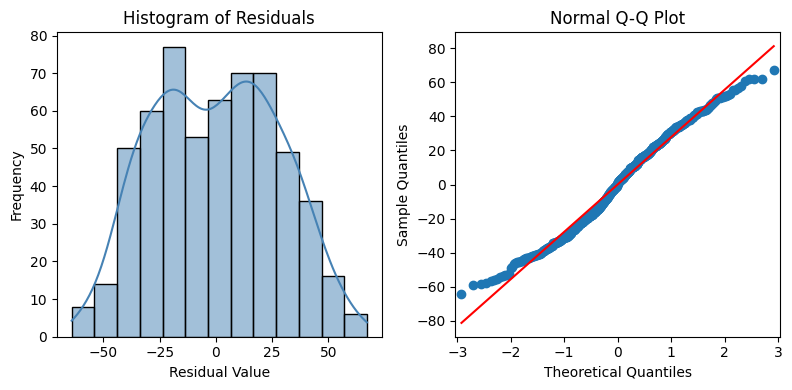

In [20]:
# Extract residuals from the fitted model
residuals = model.resid

# Initialize a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

# --- Residual Histogram ---
sns.histplot(residuals, ax=axes[0], kde=True, color="steelblue")
axes[0].set_xlabel("Residual Value", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)
axes[0].set_title("Histogram of Residuals", fontsize=12)

# --- Q-Q Plot ---
sm.qqplot(residuals, line="s", ax=axes[1])
axes[1].set_title("Normal Q-Q Plot", fontsize=12)

# Optimize layout for readability
plt.tight_layout()

# Render plots
plt.show()

Key insight:

The histogram of the residuals are approximately normally distributed, which supports that the normality assumption is met for this model. The residuals in the Q-Q plot form a straight line, further supporting that this assumption is met.

Model assumption: Constant variance

I need to check that the constant variance assumption is not violated by creating a scatterplot with the fitted values and residuals.

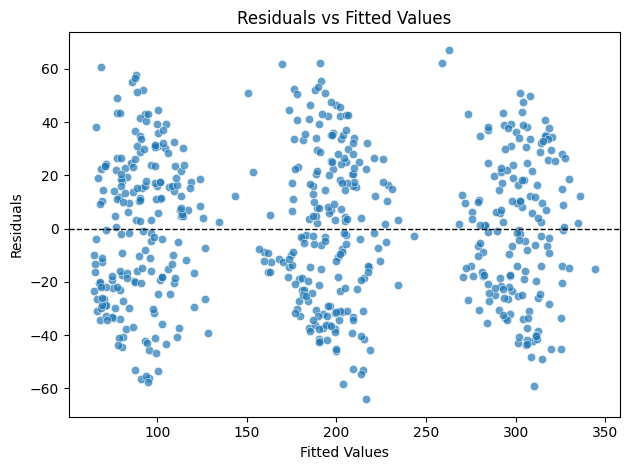

In [27]:
# --- Residual Diagnostics: Fitted Values vs Residuals ---

# Generate scatterplot of fitted values against residuals
ax = sns.scatterplot(x=model.fittedvalues, y=model.resid,  alpha=0.7)

# Configure axis labels and plot title
ax.set_xlabel("Fitted Values", fontsize=10)
ax.set_ylabel("Residuals", fontsize=10)
ax.set_title("Residuals vs Fitted Values", fontsize=12)

# Add horizontal reference line at y = 0
ax.axhline(0, color="black", linestyle="--", linewidth=1)

# Optimize layout and render plot
plt.tight_layout()
plt.show()


Key insights:

The fitted values are in three groups because the categorical variable is dominating in this model, meaning that TV is the biggest factor that decides the sales.

However, the variance where there are fitted values is similarly distributed, validating that the assumption is met.

Model assumption: No multicollinearity

The no multicollinearity assumption states that no two independent variables (
Xi
  and  
Xj
 ) can be highly correlated with each other.

Two common ways to check for multicollinearity are to:

* Create scatterplots to show the relationship between pairs of independent variables
* Use the variance inflation factor to detect multicollinearity

I use both methods to check your model's no multicollinearity assumption.

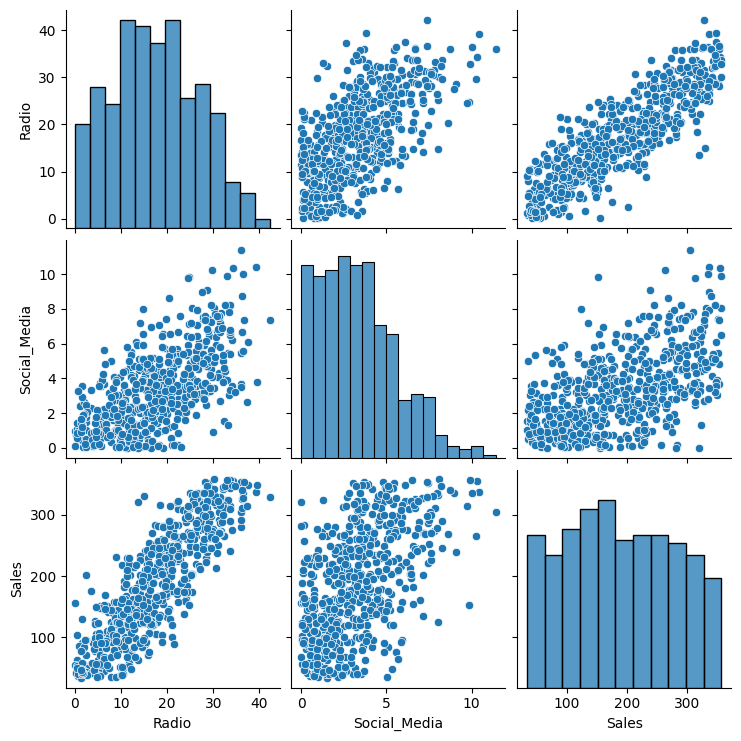

In [28]:
# Create a pairplot of the data.

sns.pairplot(data)

In [29]:
# Calculate the variance inflation factor.

# Import variance_inflation_factor from statsmodels.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a subset of the data with the continous independent variables.
X = data[['Radio','Social_Media']]

# Calculate the variance inflation factor for each variable.
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Create a DataFrame with the VIF results for the column names in X.
df_vif = pd.DataFrame(vif, index=X.columns, columns = ['VIF'])

# Display the VIF results.
df_vif

,VIF
Radio,5.170922
Social_Media,5.170922


Key insights:

The preceding model only has one continous independent variable, meaning there are no multicollinearity issues.

If a model used both Radio and Social_Media as predictors, there would be a moderate linear relationship between Radio and Social_Media that violates the multicollinearity assumption. Furthermore, the variance inflation factor when both Radio and Social_Media are included in the model is 5.17 for each variable, indicating high multicollinearity.

## Step 4: Results and evaluation

Display the OLS regression results

In [31]:
 # Display the model results summary.

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          1.63e-288
Time:                        12:41:17   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.5261      6.261     34.902      0.000     206.228     230.824
C(TV)[T.Low]     -154.2971      4.929    -31.303      0.000    -163.979    -144.616
C(TV)[T.Medium]   -75.3120      3.624    -20.780      0.000     -82.431     -68.193
Radio               2.9669      0.212     14.015      0.000       2.551       3.383
==============================================================================
Omnibus:                       61.244   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.077
Skew:                           0.046   Prob(JB):                     0.000119
Kurtosis:                       2.134   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Key insight:

* Using TV and Radio as the independent variables results in a multiple linear regression model with $R^2$ = 0.904. In other words, the model explains  90.4% of the variation in Sales. This makes the model an excellent predictor of Sales.

Interpret model coefficients

In [32]:
# Display the model results summary.

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          1.63e-288
Time:                        12:41:17   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.5261      6.261     34.902      0.000     206.228     230.824
C(TV)[T.Low]     -154.2971      4.929    -31.303      0.000    -163.979    -144.616
C(TV)[T.Medium]   -75.3120      3.624    -20.780      0.000     -82.431     -68.193
Radio               2.9669      0.212     14.015      0.000       2.551       3.383
==============================================================================
Omnibus:                       61.244   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.077
Skew:                           0.046   Prob(JB):                     0.000119
Kurtosis:                       2.134   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Key insights:

Sales = β<sub>0</sub> + β<sub>1</sub> ∗ X<sub>1</sub> + β<sub>2</sub> ∗ X<sub>2</sub> + β<sub>3</sub> ∗ X<sub>3</sub>


Sales = β<sub>0</sub> + β<sub>TVLow</sub> ∗ X<sub>TVLow</sub> +β<sub>TVMedium</sub> ∗ X<sub>TVMedium<sub/> + β<sub>Radio</sub> ∗ X<sub>Radio</sub>


Sales  = 218.5261 − 154.2971 ∗ X<sub>TVLow<sub/> − 75.3120 ∗ X<sub>TVMedium</sub> + 2.9669 ∗ X<sub>Radio</sub>

The default TV category for the model is High since there are coefficients for the other two TV categories, Medium and Low. Because the coefficients for the Medium and Low TV categories are negative, that means the average of sales is lower for Medium or Low TV categories compared to the High TV category when Radio is at the same level.
For example, the model predicts that a Low TV promotion is 154.2971 lower on average compared to a high TV promotion given the same Radio promotion.
The coefficient for Radio is positive, confirming the positive linear relationship shown earlier during the exploratory data analysis.
The p-value for all coefficients is 0.000, meaning all coefficients are statistically significant at p = 0.05. The 95% confidence intervals for each coefficient should be reported when presenting results to stakeholders.

For example, there is a 95% chance that the interval [−163.979, −144.616] contains the true parameter of the slope of β<sub>TVLow</sub>, which is the estimated difference in promotion sales when a Low TV promotion is chosen instead of a High TV promotion.

Recommendations:

High TV promotional budgets have a substantial positive influence on sales. The model estimates that switching from a high to medium TV promotional budget reduces sales by \$75.3120 million (95% CI [−82.431, −68.193]), and switching from a high to low TV promotional budget reduces sales by $154.297 million (95% CI [−163.979, −144.616]).
The model also estimates that an increase of \$1 million in the radio promotional budget will yield a \$2.9669 million increase in sales 95% CI [2.551, 3.383] ).

Thus, it is recommended that the business allot a high promotional budget to TV when possible and invest in radio promotions to increase sales.